In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
spotify = pd.read_csv("spotify_merged_clean.csv")

In [3]:
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

spotify[continuous_features] = StandardScaler().fit_transform(spotify[continuous_features])

spotify.drop(columns=['key', 'mode'], inplace=True)

# If you want a clustering input table, it can now be taken directly from spotify.
X_for_clustering = spotify[continuous_features].copy()

spotify[continuous_features]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.868896,-1.123959,-0.335257,0.919773,-0.678968,-0.512296,-0.311653,-0.160929,-0.605689
1,0.592912,-0.364169,-1.029071,-0.417897,-0.909587,0.052991,-0.538150,-1.418237,-0.063065
2,0.553037,0.493659,0.944242,0.840984,-0.732788,-0.521856,-0.688270,1.418466,1.355952
3,-0.358380,-0.891120,-1.098452,-0.567597,-0.910132,1.764826,-0.640337,-0.929284,0.276147
4,0.570126,-1.013667,-0.380699,-0.615746,-0.050149,-0.484697,-0.655612,0.359068,-0.842090
...,...,...,...,...,...,...,...,...,...
106003,0.382146,0.755092,-0.657008,-0.474801,-0.084172,2.438127,-0.609786,-1.255252,0.107221
106004,2.170802,-0.188518,0.399132,0.753440,-0.704950,-0.521837,0.004389,0.673395,0.276793
106005,-0.705858,-0.445867,0.351863,-0.585981,1.298427,-0.520496,-0.517080,0.712201,0.692663
106006,-1.816647,1.257534,0.264629,-0.037081,-0.913043,-0.501847,0.868237,-1.045701,1.737234


In [4]:
GENRE_MAPPING = {
    # Rock
    "rock": "Rock",
    "alt-rock": "Rock",
    "album rock": "Rock",
    "classic rock": "Rock",
    "hard-rock": "Rock",
    "hard rock": "Rock",
    "psych-rock": "Rock",
    "rock-n-roll": "Rock",
    "rockabilly": "Rock",
    "grunge": "Rock",
    "j-rock": "Rock",
    "permanent wave": "Rock",

    # Punk / Alternative
    "alternative": "Alternative",
    "indie": "Alternative",
    "indie-pop": "Alternative",
    "indie poptimism": "Alternative",
    "emo": "Alternative",
    "goth": "Alternative",
    "punk": "Alternative",
    "punk-rock": "Alternative",

    # Metal
    "metal": "Metal",
    "heavy-metal": "Metal",
    "death-metal": "Metal",
    "black-metal": "Metal",
    "metalcore": "Metal",
    "grindcore": "Metal",
    "groove": "Metal",
    "hardcore": "Metal",

    # Pop
    "pop": "Pop",
    "dance pop": "Pop",
    "electropop": "Pop",
    "post-teen pop": "Pop",
    "power-pop": "Pop",
    "synth-pop": "Pop",
    "j-pop": "Pop",
    "k-pop": "Pop",
    "cantopop": "Pop",
    "mandopop": "Pop",
    "latin pop": "Pop",
    "hip pop": "Pop",

    # Hip Hop / R&B
    "rap": "Hip-Hop/R&B",
    "hip-hop": "Hip-Hop/R&B",
    "hip hop": "Hip-Hop/R&B",
    "r&b": "Hip-Hop/R&B",
    "r-n-b": "Hip-Hop/R&B",
    "neo soul": "Hip-Hop/R&B",
    "new jack swing": "Hip-Hop/R&B",
    "urban contemporary": "Hip-Hop/R&B",
    "southern hip hop": "Hip-Hop/R&B",
    "latin hip hop": "Hip-Hop/R&B",
    "gangster rap": "Hip-Hop/R&B",
    "trap": "Hip-Hop/R&B",
    "soul": "Hip-Hop/R&B",

    # Electronic
    "edm": "Electronic",
    "electronic": "Electronic",
    "electro": "Electronic",
    "house": "Electronic",
    "deep-house": "Electronic",
    "chicago-house": "Electronic",
    "progressive-house": "Electronic",
    "electro house": "Electronic",
    "progressive electro house": "Electronic",
    "techno": "Electronic",
    "minimal-techno": "Electronic",
    "detroit-techno": "Electronic",
    "trance": "Electronic",
    "dubstep": "Electronic",
    "drum-and-bass": "Electronic",
    "breakbeat": "Electronic",
    "garage": "Electronic",
    "idm": "Electronic",
    "club": "Electronic",
    "dance": "Electronic",
    "hardstyle": "Electronic",
    "big room": "Electronic",
    "pop edm": "Electronic",
    "disco": "Electronic",
    "industrial": "Electronic",

    # Ambient / Chill
    "ambient": "Ambient/Chill",
    "chill": "Ambient/Chill",
    "new-age": "Ambient/Chill",
    "sleep": "Ambient/Chill",
    "study": "Ambient/Chill",
    "trip-hop": "Ambient/Chill",
    "tropical": "Ambient/Chill",

    # Folk / Country
    "folk": "Folk/Country",
    "acoustic": "Folk/Country",
    "country": "Folk/Country",
    "bluegrass": "Folk/Country",
    "honky-tonk": "Folk/Country",
    "singer-songwriter": "Folk/Country",

    # Jazz / Blues
    "jazz": "Jazz/Blues",
    "blues": "Jazz/Blues",
    "gospel": "Jazz/Blues",
    "funk": "Jazz/Blues",

    # Reggae
    "reggae": "Reggae",
    "dancehall": "Reggae",
    "dub": "Reggae",
    "ska": "Reggae",

    # Latin
    "latin": "Latin",
    "latino": "Latin",
    "reggaeton": "Latin",
    "salsa": "Latin",
    "tango": "Latin",
    "samba": "Latin",
    "pagode": "Latin",
    "mpb": "Latin",
    "sertanejo": "Latin",
    "forro": "Latin",
    "brazil": "Latin",

    # World
    "afrobeat": "World",
    "indian": "World",
    "iranian": "World",
    "turkish": "World",
    "malay": "World",
    "world-music": "World",

    # Classical
    "classical": "Classical",
    "opera": "Classical",
    "piano": "Classical",

    # Soundtracks
    "anime": "Soundtrack",
    "disney": "Soundtrack",
    "show-tunes": "Soundtrack",
    "pop-film": "Soundtrack",

    # Kids
    "children": "Kids",
    "kids": "Kids",

    # Spoken
    "comedy": "Spoken",

    # Mood
    "happy": "Mood",
    "sad": "Mood",
    "party": "Mood",
    "romance": "Mood",

    # Instrumental
    "guitar": "Instrumental",

    # Regional labels
    "british": "Regional",
    "french": "Regional",
    "german": "Regional",
    "spanish": "Regional",
    "swedish": "Regional",
    "j-idol": "Regional",
    "j-dance": "Regional",
}

In [5]:
super_genres = {genre: [] for genre in GENRE_MAPPING.values()}

for name, super_genre in GENRE_MAPPING.items():
    super_genres[super_genre].append(name)

for genre in super_genres:
    print(f"{genre:15} \tSub-genres: {super_genres[genre]}")

Rock            	Sub-genres: ['rock', 'alt-rock', 'album rock', 'classic rock', 'hard-rock', 'hard rock', 'psych-rock', 'rock-n-roll', 'rockabilly', 'grunge', 'j-rock', 'permanent wave']
Alternative     	Sub-genres: ['alternative', 'indie', 'indie-pop', 'indie poptimism', 'emo', 'goth', 'punk', 'punk-rock']
Metal           	Sub-genres: ['metal', 'heavy-metal', 'death-metal', 'black-metal', 'metalcore', 'grindcore', 'groove', 'hardcore']
Pop             	Sub-genres: ['pop', 'dance pop', 'electropop', 'post-teen pop', 'power-pop', 'synth-pop', 'j-pop', 'k-pop', 'cantopop', 'mandopop', 'latin pop', 'hip pop']
Hip-Hop/R&B     	Sub-genres: ['rap', 'hip-hop', 'hip hop', 'r&b', 'r-n-b', 'neo soul', 'new jack swing', 'urban contemporary', 'southern hip hop', 'latin hip hop', 'gangster rap', 'trap', 'soul']
Electronic      	Sub-genres: ['edm', 'electronic', 'electro', 'house', 'deep-house', 'chicago-house', 'progressive-house', 'electro house', 'progressive electro house', 'techno', 'minimal-te

Now I would like to see with different number of cluster what we are able to achieve and analyze those clusters

In [6]:
vc = spotify['macro_genre'].value_counts()
print(vc)

macro_genre
Electronic       19481
Latin            11268
Hip-Hop/R&B      10289
Pop               9431
Rock              7936
Metal             6035
Ambient/Chill     5602
Regional          5499
World             5327
Folk/Country      4492
Soundtrack        3553
Alternative       3365
Mood              3003
Reggae            2600
Classical         2256
Jazz/Blues        2189
Kids              1827
Spoken             987
Instrumental       868
Name: count, dtype: int64


# Graph 3: The Song-to-Song k-NN Graph (The "Deep Dive")

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [8]:
def build_knn_graph(
    X,
    k,
    metric="euclidean",
    symmetrization="union",
    n_jobs=-1
):
    """
    Construct a weighted undirected k-nearest-neighbor graph.

    Parameters
    ----------
    X : array-like or pandas DataFrame
        Standardized feature matrix.
    k : int
        Number of nearest neighbors per observation.
    metric : str
        Distance metric used by NearestNeighbors.
    symmetrization : {"union", "mutual"}
        union:
            Keep edge i-j if i selects j OR j selects i.
        mutual:
            Keep edge i-j only if i selects j AND j selects i.
    n_jobs : int
        Number of parallel jobs.

    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph.
    adjacency : scipy.sparse.csr_matrix
        Symmetric weighted adjacency matrix.
    """

    X_array = np.asarray(X)

    n_nodes = X_array.shape[0]

    if k >= n_nodes:
        raise ValueError(
            f"k must be smaller than the number of observations "
            f"({n_nodes}). Received k={k}."
        )

    # k + 1 because each observation is returned as its own nearest neighbor
    nn = NearestNeighbors(
        n_neighbors=k + 1,
        metric=metric,
        n_jobs=n_jobs
    )

    nn.fit(X_array)

    distances, indices = nn.kneighbors(X_array)

    # Remove the first column, corresponding to the observation itself
    distances = distances[:, 1:]
    indices = indices[:, 1:]

    rows = np.repeat(np.arange(n_nodes), k)
    cols = indices.reshape(-1)

    # Convert distances into similarities
    similarities = 1.0 / (1.0 + distances.reshape(-1))

    directed_adjacency = csr_matrix(
        (similarities, (rows, cols)),
        shape=(n_nodes, n_nodes)
    )

    if symmetrization == "union":
        # Keep the strongest weight when at least one direction exists
        adjacency = directed_adjacency.maximum(
            directed_adjacency.T
        )

    elif symmetrization == "mutual":
        # Keep only reciprocal nearest-neighbor relationships
        reciprocal_mask = (
            directed_adjacency.sign().multiply(
                directed_adjacency.T.sign()
            )
        )

        adjacency = directed_adjacency.maximum(
            directed_adjacency.T
        ).multiply(reciprocal_mask)

    else:
        raise ValueError(
            "symmetrization must be either 'union' or 'mutual'."
        )

    adjacency.setdiag(0)
    adjacency.eliminate_zeros()

    G = nx.from_scipy_sparse_array(
        adjacency,
        edge_attribute="weight"
    )

    return G, adjacency

In [9]:
def local_community_consistency(G, community_labels):
    """
    Compute the average proportion of neighbors assigned to the
    same community as each node.
    """

    node_scores = []

    for node in G.nodes():
        neighbors = list(G.neighbors(node))

        if len(neighbors) == 0:
            continue

        same_community = sum(
            community_labels[neighbor] == community_labels[node]
            for neighbor in neighbors
        )

        node_scores.append(
            same_community / len(neighbors)
        )

    if not node_scores:
        return np.nan

    return float(np.mean(node_scores))

In [10]:
def community_genre_entropy(
    community_labels,
    genre_labels
):
    """
    Compute the weighted average genre entropy across communities.
    """

    data = pd.DataFrame({
        "community": community_labels,
        "genre": genre_labels
    })

    entropies = []
    sizes = []

    for _, group in data.groupby("community"):
        probabilities = (
            group["genre"]
            .value_counts(normalize=True)
            .to_numpy()
        )

        entropy = -np.sum(
            probabilities * np.log2(probabilities)
        )

        entropies.append(entropy)
        sizes.append(len(group))

    return float(
        np.average(entropies, weights=sizes)
    )

In [11]:
def normalized_community_genre_entropy(
    community_labels,
    genre_labels
):
    data = pd.DataFrame({
        "community": community_labels,
        "genre": genre_labels
    })

    n_genres = data["genre"].nunique()

    if n_genres <= 1:
        return 0.0

    raw_entropy = community_genre_entropy(
        community_labels,
        genre_labels
    )

    return raw_entropy / np.log2(n_genres)

In [23]:
def compute_group_dispersion(X, labels):
    """
    Compute acoustic dispersion within groups.

    For each group:
        dispersion = mean Euclidean distance of observations
                     from the group centroid.

    Parameters
    ----------
    X : array-like or pandas DataFrame
        Standardized acoustic feature matrix.

    labels : array-like
        Group assignment for each observation.

    Returns
    -------
    group_dispersion_df : pandas DataFrame
        Dispersion and size for each group.

    weighted_mean_dispersion : float
        Mean dispersion weighted by group size.

    unweighted_mean_dispersion : float
        Mean of the group-level dispersions.
    """

    X_array = np.asarray(X)
    labels_array = np.asarray(labels)

    if len(X_array) != len(labels_array):
        raise ValueError(
            "X and labels must contain the same number of observations."
        )

    rows = []

    for group in np.unique(labels_array):
        mask = labels_array == group
        X_group = X_array[mask]

        centroid = X_group.mean(axis=0)

        distances = np.linalg.norm(
            X_group - centroid,
            axis=1
        )

        rows.append({
            "group": group,
            "size": len(X_group),
            "dispersion": distances.mean()
        })

    group_dispersion_df = pd.DataFrame(rows)

    weighted_mean_dispersion = np.average(
        group_dispersion_df["dispersion"],
        weights=group_dispersion_df["size"]
    )

    unweighted_mean_dispersion = (
        group_dispersion_df["dispersion"].mean()
    )

    return (
        group_dispersion_df,
        weighted_mean_dispersion,
        unweighted_mean_dispersion
    )

def evaluate_knn_graph(
    X,
    genre_labels,
    k,
    metric="euclidean",
    symmetrization="union",
    clustering_sample_size=5000,
    random_state=42
):
    """
    Construct and evaluate a k-NN similarity graph.
    """

    genre_labels = pd.Series(genre_labels).reset_index(drop=True)

    if len(genre_labels) != len(X):
        raise ValueError(
            "X and genre_labels must contain the same number of rows."
        )

    G, adjacency = build_knn_graph(
        X=X,
        k=k,
        metric=metric,
        symmetrization=symmetrization
    )

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # ---------------------------------------------------------
    # Basic graph properties
    # ---------------------------------------------------------

    n_components = nx.number_connected_components(G)

    component_sizes = [
        len(component)
        for component in nx.connected_components(G)
    ]

    giant_component_size = max(component_sizes)

    giant_component_fraction = (
        giant_component_size / n_nodes
    )

    average_degree = (
        2 * n_edges / n_nodes
        if n_nodes > 0
        else np.nan
    )

    density = nx.density(G)

    # ---------------------------------------------------------
    # Approximate average clustering coefficient
    # ---------------------------------------------------------

    rng = np.random.default_rng(random_state)

    if n_nodes > clustering_sample_size:
        sampled_nodes = rng.choice(
            list(G.nodes()),
            size=clustering_sample_size,
            replace=False
        ).tolist()
    else:
        sampled_nodes = list(G.nodes())

    average_clustering = nx.average_clustering(
        G,
        nodes=sampled_nodes,
        weight="weight"
    )

    # ---------------------------------------------------------
    # Genre assortativity
    # ---------------------------------------------------------

    genre_attribute = {
        node: genre_labels.iloc[node]
        for node in G.nodes()
    }

    nx.set_node_attributes(
        G,
        genre_attribute,
        "genre"
    )

    genre_assortativity = (
        nx.attribute_assortativity_coefficient(
            G,
            "genre"
        )
    )

    # ---------------------------------------------------------
    # Louvain community detection
    # ---------------------------------------------------------

    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=1.0,
        seed=random_state
    )

    modularity = nx.community.modularity(
        G,
        communities,
        weight="weight"
    )

    community_labels = np.empty(
        n_nodes,
        dtype=int
    )

    for community_id, community_nodes in enumerate(communities):
        for node in community_nodes:
            community_labels[node] = community_id

    n_communities = len(communities)

    community_sizes = np.array(
        [len(community) for community in communities]
    )

    # ---------------------------------------------------------
    # Agreement with genre labels
    # ---------------------------------------------------------

    ari = adjusted_rand_score(
        genre_labels,
        community_labels
    )

    nmi = normalized_mutual_info_score(
        genre_labels,
        community_labels
    )

    # ---------------------------------------------------------
    # Local community consistency
    # ---------------------------------------------------------

    local_consistency = local_community_consistency(
        G,
        community_labels
    )

    # ---------------------------------------------------------
    # Semantic mixing
    # ---------------------------------------------------------

    normalized_entropy = (
        normalized_community_genre_entropy(
            community_labels,
            genre_labels
        )
    )

    _, community_weighted_dispersion, _ = compute_group_dispersion(
        X,
        community_labels
    )

    result = {
        "k": k,
        "nodes": n_nodes,
        "edges": n_edges,
        "average_degree": average_degree,
        "density": density,
        "connected_components": n_components,
        "giant_component_fraction": giant_component_fraction,
        "average_clustering": average_clustering,
        "genre_assortativity": genre_assortativity,
        "communities": n_communities,
        "modularity": modularity,
        "local_community_consistency": local_consistency,
        "community_genre_entropy": normalized_entropy,
        "ARI_genre_community": ari,
        "NMI_genre_community": nmi,
        "community_dispersion": community_weighted_dispersion,
        "smallest_community": community_sizes.min(),
        "median_community_size": np.median(community_sizes),
        "largest_community": community_sizes.max()
    }

    return result, G, community_labels

In [14]:
genre_labels = spotify.loc[
    X_for_clustering.index,
    "macro_genre"
].reset_index(drop=True)

In [19]:
k_values = [3, 5, 8, 10, 15]

results = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    results.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

results_df = pd.DataFrame(results)

Evaluating k=3...
Evaluating k=5...
Evaluating k=8...
Evaluating k=10...
Evaluating k=15...


In [20]:
results_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,3,228133,4.3041,6,0.9998,0.1414,0.1995,46,0.8639,0.8848,0.7651,0.0486,0.1346
1,5,372734,7.0322,1,1.0000,0.1507,0.1937,29,0.8350,0.8680,0.7717,0.0703,0.1357
2,8,588677,11.1063,1,1.0000,0.1569,0.1893,23,0.8102,0.8523,0.7752,0.0696,0.1368
3,10,732756,13.8245,1,1.0000,0.1592,0.1871,24,0.7979,0.8386,0.7715,0.0818,0.1397
4,15,1094491,20.6492,1,1.0000,0.1613,0.1830,20,0.7920,0.8405,0.7815,0.0615,0.1330


In [21]:
k_values = [3, 5, 8, 10, 15]

results_cosine = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        metric="cosine",
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    results_cosine.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

results_cosine_df = pd.DataFrame(results_cosine)

Evaluating k=3...
Evaluating k=5...
Evaluating k=8...
Evaluating k=10...
Evaluating k=15...


In [22]:
results_cosine_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,3,228623,4.3133,2,1.0,0.2164,0.1988,38,0.8717,0.8969,0.7660,0.0461,0.1346
1,5,373603,7.0486,1,1.0,0.2384,0.1935,26,0.8433,0.8777,0.7729,0.0609,0.1350
2,8,590278,11.1365,1,1.0,0.2515,0.1895,22,0.8214,0.8615,0.7761,0.0672,0.1355
3,10,734911,13.8652,1,1.0,0.2574,0.1871,21,0.8121,0.8546,0.7804,0.0592,0.1324
4,15,1095432,20.6670,1,1.0,0.2675,0.1834,19,0.7968,0.8451,0.7849,0.0643,0.1304


In [24]:
k_values = [5, 8]

euclidean_results = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    euclidean_results.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

euclidean_results_df = pd.DataFrame(euclidean_results)

Evaluating k=5...
Evaluating k=8...


In [29]:
_, genre_dispersion, _ = compute_group_dispersion(
    X_for_clustering,
    genre_labels
)

print("Genre dispersion:", genre_dispersion)

Genre dispersion: 2.4979153371964316


In [27]:
euclidean_results_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_dispersion",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_dispersion,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,5,372734,7.0322,1,1.0,0.1507,0.1937,29,0.8350,0.8680,1.6549,0.7717,0.0703,0.1357
1,8,588677,11.1063,1,1.0,0.1569,0.1893,23,0.8102,0.8523,1.7167,0.7752,0.0696,0.1368


In [28]:
k_values = [5, 8]

cosine_results = []

for k in k_values:
    print(f"Evaluating k={k}...")

    result, G, community_labels = evaluate_knn_graph(
        X=X_for_clustering,
        genre_labels=genre_labels,
        k=k,
        metric="cosine",
        symmetrization="union",
        clustering_sample_size=5000,
        random_state=42
    )

    cosine_results.append(result)

    # Explicitly remove large objects before constructing the next graph
    del G
    del community_labels

cosine_results_df = pd.DataFrame(cosine_results)

Evaluating k=5...
Evaluating k=8...


In [30]:
cosine_results_df[
    [
        "k",
        "edges",
        "average_degree",
        "connected_components",
        "giant_component_fraction",
        "average_clustering",
        "genre_assortativity",
        "communities",
        "modularity",
        "local_community_consistency",
        "community_dispersion",
        "community_genre_entropy",
        "ARI_genre_community",
        "NMI_genre_community"
    ]
].round(4)

,k,edges,average_degree,connected_components,giant_component_fraction,average_clustering,genre_assortativity,communities,modularity,local_community_consistency,community_dispersion,community_genre_entropy,ARI_genre_community,NMI_genre_community
0,5,373603,7.0486,1,1.0,0.2384,0.1935,26,0.8433,0.8777,1.6760,0.7729,0.0609,0.1350
1,8,590278,11.1365,1,1.0,0.2515,0.1895,22,0.8214,0.8615,1.7348,0.7761,0.0672,0.1355


In [ ]:
print(cosine_results_df[cosine_results_df["k"] == 5])

   k   nodes   edges  average_degree   density  connected_components  \
0  5  106008  373603        7.048581  0.000066                     1   

   giant_component_fraction  average_clustering  genre_assortativity  \
0                       1.0            0.238373             0.193504   

   communities  modularity  local_community_consistency  \
0           26    0.843254                     0.877654   

   community_genre_entropy  ARI_genre_community  NMI_genre_community  \
0                   0.7729             0.060932             0.134962   

   community_dispersion  smallest_community  median_community_size  \
0              1.675997                1073                 4074.0   

   largest_community  
0               6979  


In [15]:
result, G, community_labels = evaluate_knn_graph(
    X=X_for_clustering,
    genre_labels=genre_labels,
    k=5,
    metric="cosine",
    symmetrization="union",
    clustering_sample_size=5000,
    random_state=42
)

In [16]:
print(result)

{'k': 5, 'nodes': 106008, 'edges': 373603, 'average_degree': 7.048581239151762, 'density': 6.649165846738199e-05, 'connected_components': 1, 'giant_component_fraction': 1.0, 'average_clustering': 0.23837273351374846, 'genre_assortativity': 0.1935037441938744, 'communities': 26, 'modularity': 0.8432536294317441, 'local_community_consistency': 0.8776544820993117, 'community_genre_entropy': np.float64(0.7728996734048714), 'ARI_genre_community': 0.06093222141860891, 'NMI_genre_community': 0.13496188233219472, 'community_dispersion': np.float64(1.675996545052699), 'smallest_community': np.int64(1073), 'median_community_size': np.float64(4074.0), 'largest_community': np.int64(6979)}


In [ ]:
from pathlib import Path
import pickle
import numpy as np
import json

def save_graph_analysis(
    G,
    community_labels,
    result,
    metric,
    k,
    output_dir="network_results"
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    prefix = f"{metric}_k{k}"

    # Graph
    with open(output_dir / f"graph_{prefix}.pkl", "wb") as f:
        pickle.dump(G, f)

    # Communities
    np.save(
        output_dir / f"communities_{prefix}.npy",
        community_labels
    )

    # Metrics
    with open(output_dir / f"metrics_{prefix}.json", "w") as f:
        json.dump(
            result,
            f,
            indent=4,
            default=float
        )

    print(f"Saved: {prefix}")

def load_graph_analysis(
    metric,
    k,
    output_dir="network_results"
):
    output_dir = Path(output_dir)
    prefix = f"{metric}_k{k}"

    with open(output_dir / f"graph_{prefix}.pkl", "rb") as f:
        G = pickle.load(f)

    community_labels = np.load(
        output_dir / f"communities_{prefix}.npy"
    )

    with open(output_dir / f"metrics_{prefix}.json", "r") as f:
        result = json.load(f)

    return result, G, community_labels

In [19]:
save_graph_analysis(
    G=G,
    community_labels=community_labels,
    result=result,
    metric="cosine",
    k=5
)

Saved: cosine_k5


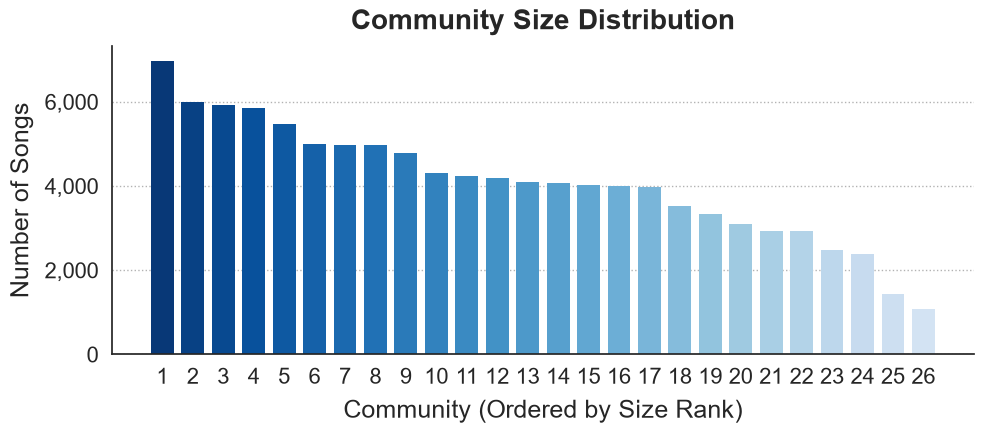

,community,size
0,3,6979
1,17,5997
2,7,5912
3,14,5855
4,8,5471
5,10,5001
6,6,4985
7,9,4975
8,23,4778
9,0,4309


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12

# 1. Prepare data
community_sizes = (
    pd.Series(community_labels, name="community")
    .value_counts()
    .sort_values(ascending=False)
    .reset_index()
)
community_sizes.columns = ["community", "size"]

# 2. Set publication style
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 4.5))

# Create a subtle continuous blue palette to emphasize size rank
colors = sns.color_palette("Blues_r", n_colors=len(community_sizes) + 5)[
    : len(community_sizes)
]

# 3. Plot bars with custom color, rounded edge line, and slight spacing
bars = ax.bar(
    range(1, len(community_sizes) + 1),
    community_sizes["size"],
    color=colors,
    edgecolor="none",
    width=0.75,
)

# 4. Refine Axes and Grid
ax.set_xlabel("Community (Ordered by Size Rank)", fontsize=LABEL_SIZE, labelpad=8)
ax.set_ylabel("Number of Songs", fontsize=LABEL_SIZE, labelpad=8)
ax.set_title(
    "Community Size Distribution", fontsize=TITLE_SIZE, fontweight="bold", pad=12
)

# Set precise X-ticks
ax.set_xticks(range(1, len(community_sizes) + 1))
ax.tick_params(axis="both", which="major", labelsize=TICKS_SIZE)

# Format Y-axis numbers with thousands commas (e.g., 7,000 instead of 7000)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

# Clean spines and add light horizontal gridlines behind bars
sns.despine(ax=ax)
ax.grid(axis="y", linestyle=":", alpha=0.6, color="gray")
ax.set_axisbelow(True)

plt.tight_layout()

# Save high-res vector PDF for LaTeX integration
plt.savefig("community_size_distribution.pdf", bbox_inches="tight")
plt.show()

display(community_sizes)

In [26]:
# --------------------------------------------------------
# Community × Genre contingency table
# --------------------------------------------------------

community_genre = pd.crosstab(
    pd.Series(community_labels, name="Community"),
    pd.Series(genre_labels, name="Genre")
)

# --------------------------------------------------------
# Order communities by size
# --------------------------------------------------------

community_order = (
    community_genre.sum(axis=1)
    .sort_values(ascending=False)
    .index
)

genre_order = [
    "Electronic",
    "Hip-Hop/R&B",
    "Pop",
    "Latin",
    "Rock",
]

remaining = [
    g for g in community_genre.columns
    if g not in genre_order
]

genre_order = genre_order + sorted(remaining)

community_genre = community_genre.loc[
    community_order,
    genre_order
]

# --------------------------------------------------------
# Normalize
# --------------------------------------------------------

# Each row sums to 1:
# composition of each community
community_to_genre = community_genre.div(
    community_genre.sum(axis=1),
    axis=0
)

# Each column sums to 1:
# distribution of each genre across communities
genre_to_community = community_genre.div(
    community_genre.sum(axis=0),
    axis=1
)

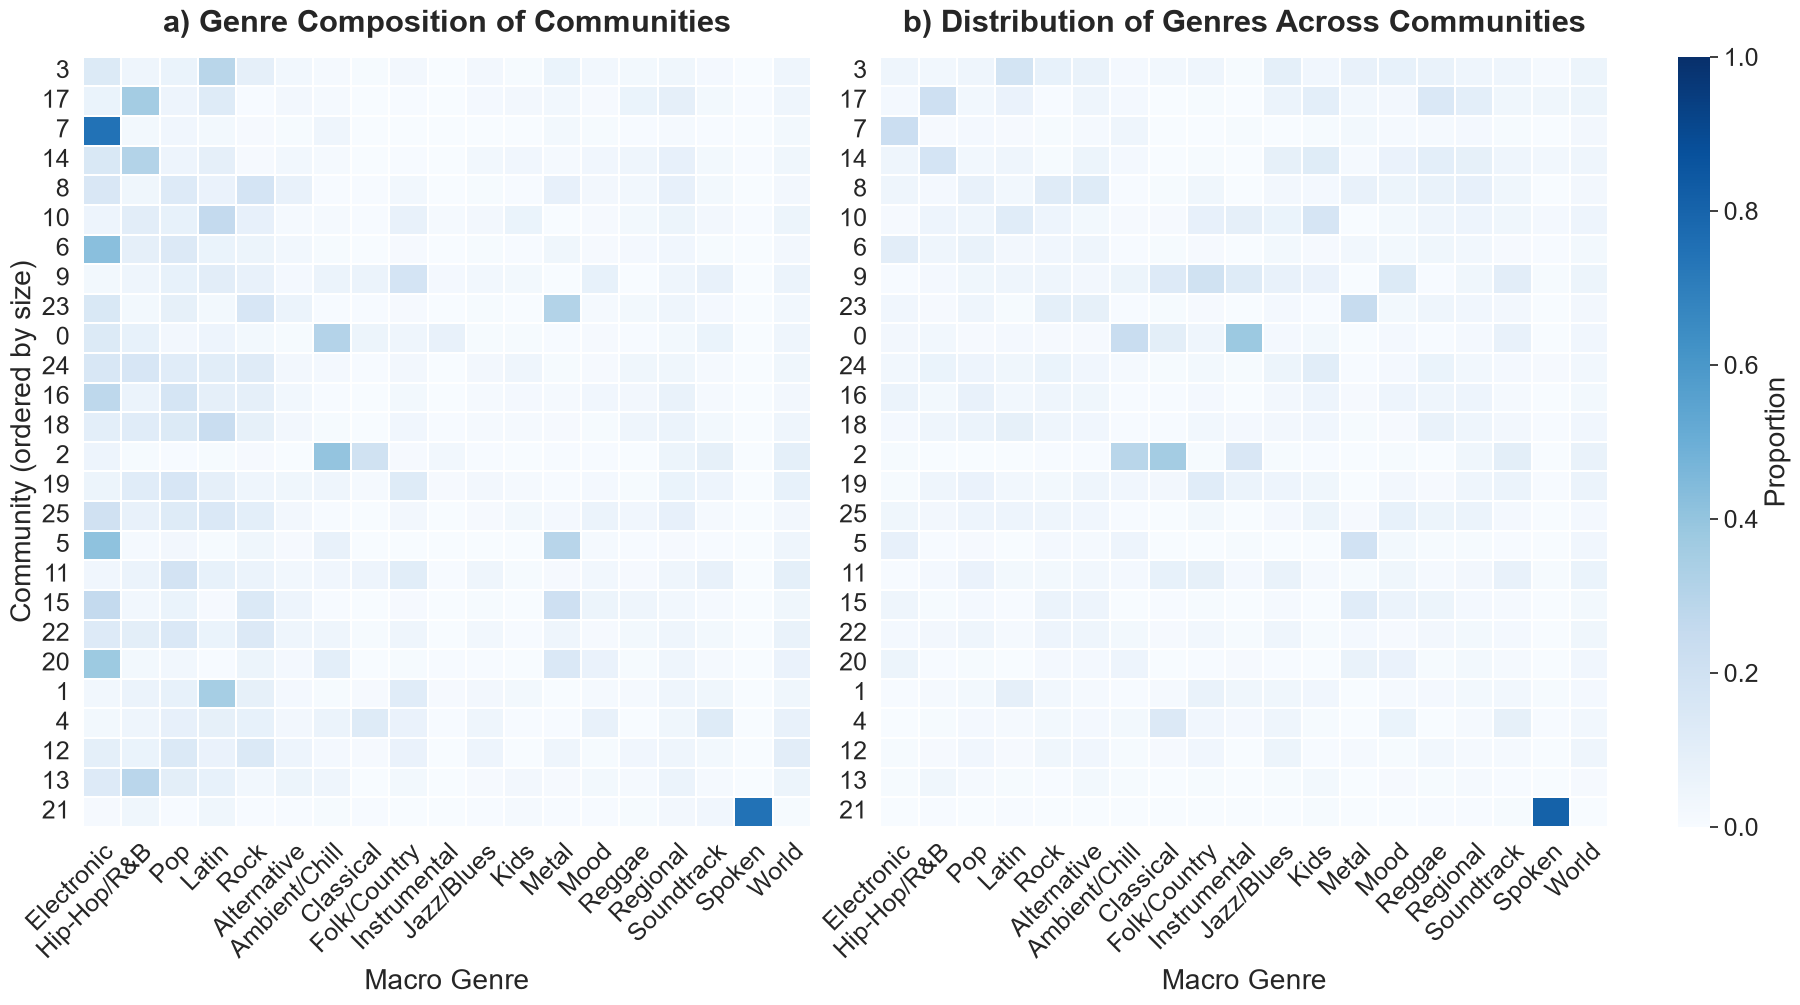

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TITLE_SIZE = 22
LABEL_SIZE = 20
TICKS_SIZE = 18
CBAR_TICKS_SIZE = 18



# --------------------------------------------------------
# Figure with shared colorbar
# --------------------------------------------------------

fig = plt.figure(figsize=(21, 10))

gs = fig.add_gridspec(
    1, 3,
    width_ratios=[1, 1, 0.045],
    wspace=0.14
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cbar_ax = fig.add_subplot(gs[0, 2])

# --------------------------------------------------------
# Panel A
# --------------------------------------------------------

sns.heatmap(
    community_to_genre,
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.35,
    linecolor="white",
    cbar=False,
    ax=ax1
)

ax1.set_title(
    "a) Genre Composition of Communities",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=18
)

ax1.set_xlabel(
    "Macro Genre",
    fontsize=LABEL_SIZE
)

ax1.set_ylabel(
    "Community (ordered by size)",
    fontsize=LABEL_SIZE
)

# --------------------------------------------------------
# Panel B
# --------------------------------------------------------

hm = sns.heatmap(
    genre_to_community,
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.35,
    linecolor="white",
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={"label": "Proportion"},
    ax=ax2
)

ax2.set_title(
    "b) Distribution of Genres Across Communities",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=18
)

ax2.set_xlabel(
    "Macro Genre",
    fontsize=LABEL_SIZE
)

ax2.set_ylabel("")

# --------------------------------------------------------
# Tick formatting
# --------------------------------------------------------

for ax in [ax1, ax2]:

    ax.tick_params(
        axis="y",
        labelsize=TICKS_SIZE,
        labelrotation=0
    )

    ax.tick_params(
        axis="x",
        labelsize=TICKS_SIZE
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

# --------------------------------------------------------
# Shared colorbar formatting
# --------------------------------------------------------

cbar = hm.collections[0].colorbar

cbar.ax.tick_params(
    labelsize=CBAR_TICKS_SIZE
)

cbar.ax.yaxis.label.set_size(LABEL_SIZE)

# --------------------------------------------------------
# Save
# --------------------------------------------------------

plt.savefig(
    "community_genre_bidirectional_heatmaps.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "community_genre_bidirectional_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
community,,,,,,,,,
4,-0.51,-1.17,-0.60,-0.42,1.40,-0.46,-0.25,-0.30,-0.95
17,0.65,0.46,0.00,-0.23,-0.73,1.77,-0.47,-0.10,0.24
0,-0.25,0.24,0.19,-0.15,0.03,-0.47,2.52,0.10,0.03
13,0.81,0.05,0.21,1.42,-0.20,-0.50,-0.15,0.43,-0.93
18,0.63,0.18,0.33,1.63,-0.25,-0.49,-0.21,0.27,1.00
3,-0.25,-1.39,-1.63,-0.26,1.35,2.07,-0.42,-0.49,-0.18
14,0.11,0.67,0.61,-0.34,-0.76,-0.47,-0.47,-0.45,0.24
19,-0.76,0.90,0.39,-0.06,-0.83,1.63,0.42,-0.84,0.37
1,0.72,0.01,0.26,-0.32,0.75,-0.50,-0.32,1.16,-0.46


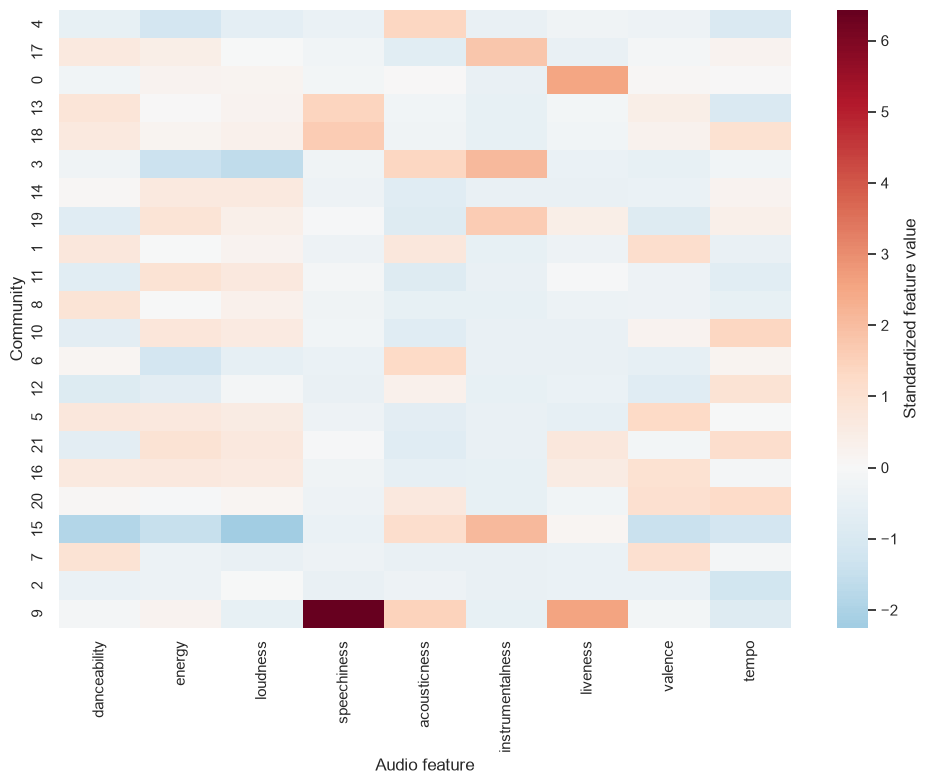

In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# Feature names
# -----------------------------------------

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

# -----------------------------------------
# Build dataframe of standardized features
# -----------------------------------------

feature_df = pd.DataFrame(
    X_for_clustering,
    columns=audio_features
)

feature_df["community"] = community_labels
feature_df["genre"] = genre_labels

# -----------------------------------------
# Community centroids
# -----------------------------------------

community_centroids = (
    feature_df
    .groupby("community")[audio_features]
    .mean()
)

# Order by community size
community_order = (
    feature_df["community"]
    .value_counts()
    .index
)

community_centroids = community_centroids.loc[community_order]

display(community_centroids.round(2))

# -----------------------------------------
# Heatmap
# -----------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(
    community_centroids,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label":"Standardized feature value"}
)

plt.xlabel("Audio feature")
plt.ylabel("Community")

plt.tight_layout()

plt.savefig(
    "community_feature_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

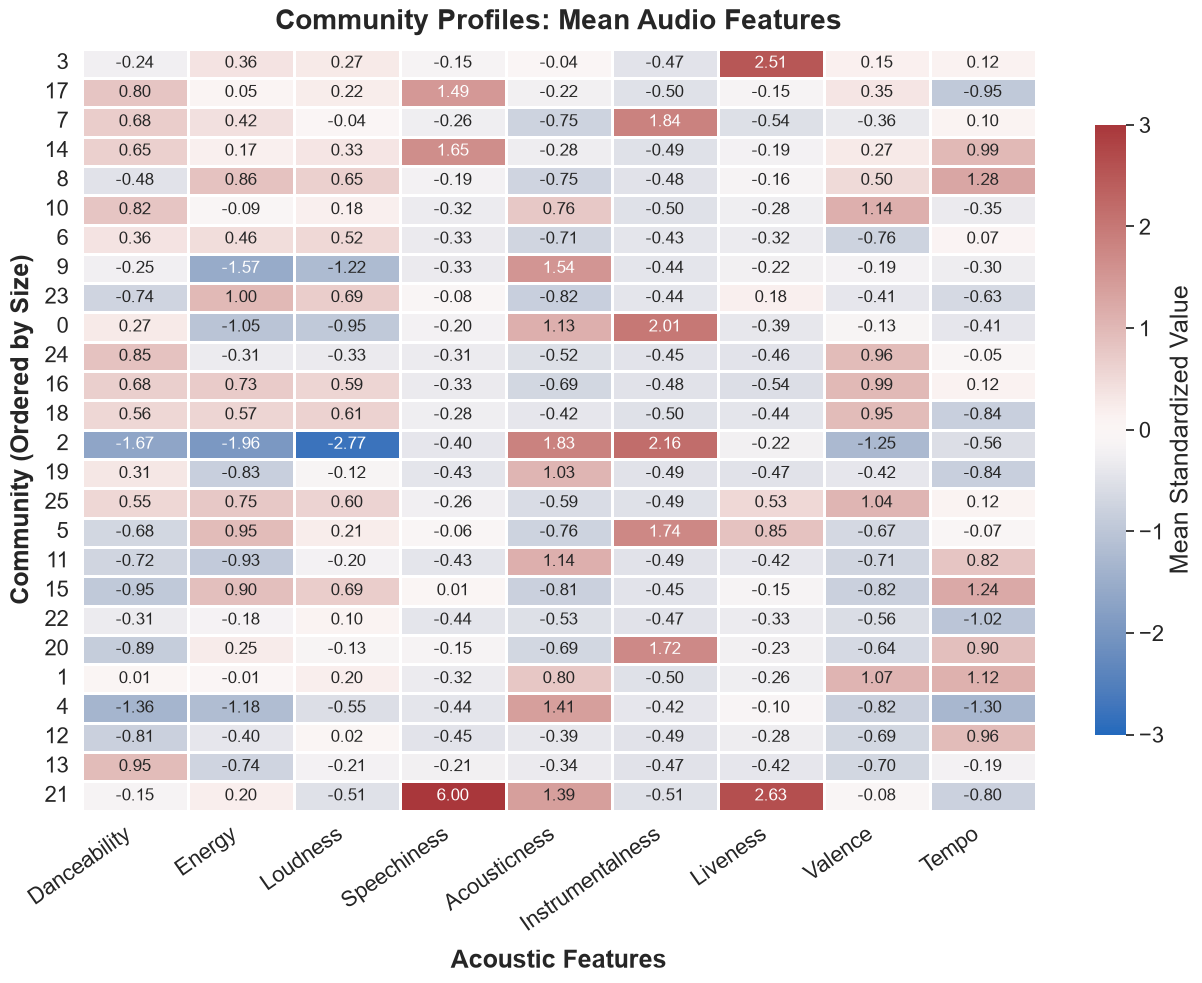

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TITLE_SIZE = 20
LABEL_SIZE = 18
TICKS_SIZE = 16
ANNOT_SIZE = 12

# -----------------------------------------
# Feature names
# -----------------------------------------

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

# -----------------------------------------
# Build dataframe of standardized features
# -----------------------------------------

feature_df = pd.DataFrame(
    X_for_clustering,
    columns=audio_features
)

feature_df["community"] = community_labels
feature_df["genre"] = genre_labels

# -----------------------------------------
# Community centroids
# -----------------------------------------

community_centroids = (
    feature_df
    .groupby("community")[audio_features]
    .mean()
)

# Order communities by size
community_order = (
    feature_df["community"]
    .value_counts()
    .index
)

community_centroids = community_centroids.loc[community_order]

# -----------------------------------------
# Annotation matrix
# -----------------------------------------

annot_matrix = community_centroids.copy()

for col in annot_matrix.columns:
    annot_matrix[col] = annot_matrix[col].map("{:.2f}".format)

# -----------------------------------------
# Publication style
# -----------------------------------------

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 10))

# -----------------------------------------
# Heatmap
# -----------------------------------------

sns.heatmap(
    community_centroids,
    annot=annot_matrix.values,
    fmt="",
    cmap="vlag",
    center=0,
    linewidths=0.75,
    linecolor="white",
    vmin=-3,
    vmax=3,
    cbar_kws={
        "shrink": 0.8,
        "label": "Mean Standardized Value",
    },
    annot_kws={
        "size": ANNOT_SIZE,
        "weight": "medium"
    },
    ax=ax,
)

# -----------------------------------------
# Colorbar formatting
# -----------------------------------------

cbar_axes = ax.collections[0].colorbar.ax

cbar_axes.yaxis.label.set_size(LABEL_SIZE)
cbar_axes.tick_params(labelsize=TICKS_SIZE)

# -----------------------------------------
# Titles and labels
# -----------------------------------------

ax.set_title(
    "Community Profiles: Mean Audio Features",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=14,
)

ax.set_ylabel(
    "Community (Ordered by Size)",
    fontsize=LABEL_SIZE,
    fontweight="bold",
    labelpad=8
)

ax.set_xlabel(
    "Acoustic Features",
    fontsize=LABEL_SIZE,
    fontweight="bold",
    labelpad=10
)

# -----------------------------------------
# Tick formatting
# -----------------------------------------

ax.set_xticklabels(
    [col.capitalize() for col in audio_features],
    rotation=35,
    ha="right",
    fontsize=TICKS_SIZE,
)

ax.set_yticklabels(
    [f"{c}" for c in community_centroids.index],
    rotation=0,
    fontsize=TICKS_SIZE,
)

# -----------------------------------------
# Layout and save
# -----------------------------------------

plt.tight_layout()

plt.savefig(
    "community_feature_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "community_feature_heatmap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
community,,,,,,,,,
0,0.27,-1.05,-0.95,-0.20,1.13,2.01,-0.39,-0.13,-0.41
1,0.01,-0.01,0.20,-0.32,0.80,-0.50,-0.26,1.07,1.12
2,-1.67,-1.96,-2.77,-0.40,1.83,2.16,-0.22,-1.25,-0.56
3,-0.24,0.36,0.27,-0.15,-0.04,-0.47,2.51,0.15,0.12
4,-1.36,-1.18,-0.55,-0.44,1.41,-0.42,-0.10,-0.82,-1.30
5,-0.68,0.95,0.21,-0.06,-0.76,1.74,0.85,-0.67,-0.07
6,0.36,0.46,0.52,-0.33,-0.71,-0.43,-0.32,-0.76,0.07
7,0.68,0.42,-0.04,-0.26,-0.75,1.84,-0.54,-0.36,0.10
8,-0.48,0.86,0.65,-0.19,-0.75,-0.48,-0.16,0.50,1.28


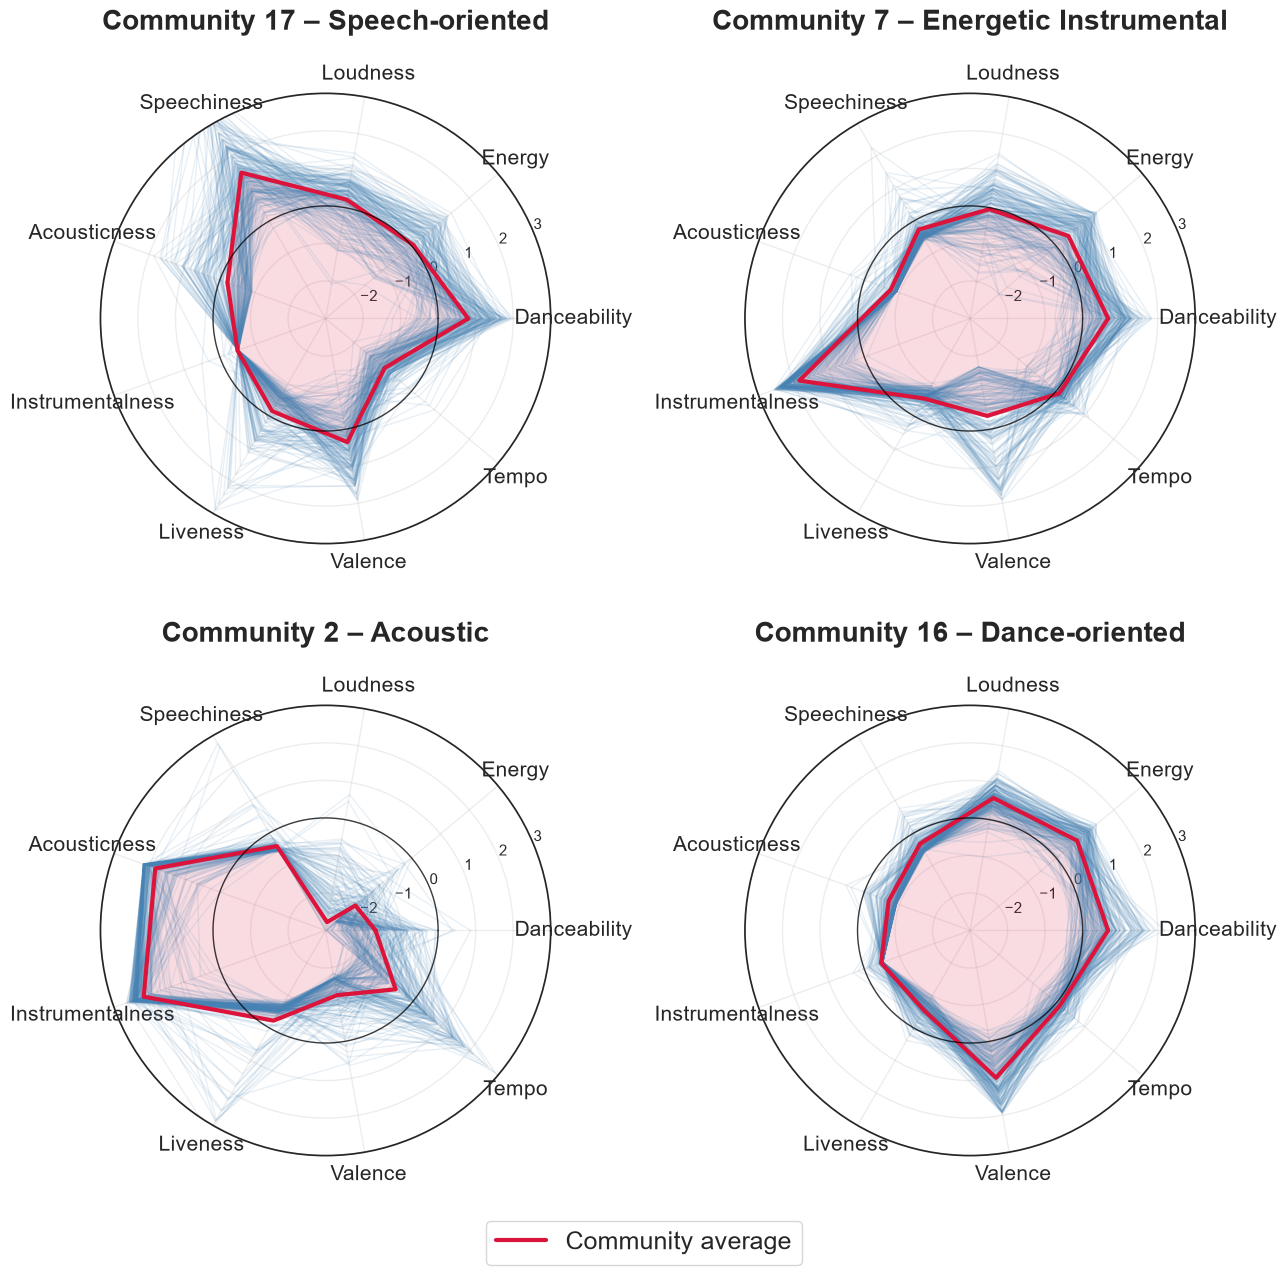

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========================================================
# STYLE
# ========================================================

TITLE_SIZE = 20
LABEL_SIZE = 15
TICKS_SIZE = 11
LEGEND_SIZE = 18

# ========================================================
# BUILD FEATURE DATAFRAME
# X_for_clustering is assumed to already contain
# standardized continuous features
# ========================================================

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

feature_df = pd.DataFrame(
    X_for_clustering,
    columns=audio_features
)

feature_df["community"] = community_labels
feature_df["genre"] = genre_labels

# ========================================================
# COMMUNITY MEAN PROFILES
# Since X_for_clustering is already standardized,
# these are mean Z-score profiles
# ========================================================

comm_scaled = (
    feature_df
    .groupby("community")[audio_features]
    .mean()
)

display(comm_scaled.round(2))


# ========================================================
# RADAR PLOT FUNCTION
# ========================================================

def plot_representative_communities(
    communities,
    titles=None,
    sample_size=20,
    radial_limits=(-3, 3),
    radial_tick_step=1
):
    categories = audio_features
    N = len(categories)

    # Angles for radar axes
    angles = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    ).tolist()

    # Close the polygon
    angles += angles[:1]

    if titles is None:
        titles = [
            f"Community {c}"
            for c in communities
        ]

    # ----------------------------------------------------
    # Create figure
    # ----------------------------------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13, 13),
        subplot_kw=dict(polar=True)
    )

    axes = axes.flatten()

    # Same radial ticks for all radar plots
    radial_ticks = np.arange(
        radial_limits[0],
        radial_limits[1] + radial_tick_step,
        radial_tick_step
    )

    # ----------------------------------------------------
    # Plot each community
    # ----------------------------------------------------

    for ax, comm_id, title in zip(
        axes,
        communities,
        titles
    ):

        # -----------------------------------------------
        # Community mean profile
        # -----------------------------------------------

        avg_values = (
            comm_scaled
            .loc[comm_id]
            .values
            .tolist()
        )

        avg_values += avg_values[:1]

        # -----------------------------------------------
        # Sample individual songs from the community
        # -----------------------------------------------

        comm_songs = feature_df[
            feature_df["community"] == comm_id
        ]

        sample = (
            comm_songs[audio_features]
            .sample(
                min(sample_size, len(comm_songs)),
                random_state=42
            )
        )

        # Already standardized -> NO additional scaling
        sample_values = sample.to_numpy()

        # -----------------------------------------------
        # Plot sampled songs
        # -----------------------------------------------

        for row in sample_values:

            vals = row.tolist()
            vals += vals[:1]

            ax.plot(
                angles,
                vals,
                color="steelblue",
                alpha=0.12,
                linewidth=1
            )

        # -----------------------------------------------
        # Plot community mean
        # -----------------------------------------------

        ax.plot(
            angles,
            avg_values,
            color="crimson",
            linewidth=3,
            label="Community average"
        )

        ax.fill(
            angles,
            avg_values,
            color="crimson",
            alpha=0.15
        )

        # -----------------------------------------------
        # Feature labels
        # -----------------------------------------------

        ax.set_xticks(
            angles[:-1]
        )

        ax.set_xticklabels(
            [
                feature.capitalize()
                for feature in categories
            ],
            fontsize=LABEL_SIZE
        )

        # -----------------------------------------------
        # Common radial scale
        # -----------------------------------------------

        ax.set_ylim(
            *radial_limits
        )

        ax.set_yticks(
            radial_ticks
        )

        ax.tick_params(
            axis="y",
            labelsize=TICKS_SIZE
        )

        # Position radial labels
        ax.set_rlabel_position(22.5)

        # -----------------------------------------------
        # Title
        # -----------------------------------------------

        ax.set_title(
            title,
            fontsize=TITLE_SIZE,
            fontweight="bold",
            pad=25
        )

        # -----------------------------------------------
        # Grid
        # -----------------------------------------------

        ax.grid(
            alpha=0.35
        )

        # Thin black reference circle at z = 0
        theta_zero = np.linspace(
            0,
            2 * np.pi,
            500
        )

        ax.plot(
            theta_zero,
            np.zeros_like(theta_zero),
            color="black",
            linewidth=1.0,
            alpha=0.75,
            zorder=5
        )

    # ----------------------------------------------------
    # Shared legend
    # ----------------------------------------------------

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=1,
        fontsize=LEGEND_SIZE
    )

    # ----------------------------------------------------
    # Layout
    # ----------------------------------------------------

    plt.tight_layout(
        rect=[0, 0.05, 1, 1],
        h_pad=1.5,
        w_pad=1.5
    )

    # ----------------------------------------------------
    # Save
    # ----------------------------------------------------

    plt.savefig(
        "community_radar_profiles.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        "community_radar_profiles.pdf",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ========================================================
# EXAMPLE CALL
# ========================================================

plot_representative_communities(
    communities=[17, 7, 2, 16],
    titles=[
        "Community 17 – Speech-oriented",
        "Community 7 – Energetic Instrumental",
        "Community 2 – Acoustic",
        "Community 16 – Dance-oriented"
    ],
    sample_size=200,
    radial_limits=(-3, 3),
    radial_tick_step=1
)

In [80]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine, euclidean

analysis_df = feature_df.dropna(
    subset=continuous_features + ["community"]
).copy()

analysis_df["community"] = analysis_df["community"].astype(int)

# Community centroids
community_centroids = (
    analysis_df
    .groupby("community")[continuous_features]
    .mean()
)


def community_centroid_metrics(row):
    community_id = row["community"]

    song_vector = row[continuous_features].to_numpy(dtype=float)
    centroid_vector = (
        community_centroids
        .loc[community_id]
        .to_numpy(dtype=float)
    )

    return pd.Series({
        "centroid_cosine_similarity":
            1 - cosine(song_vector, centroid_vector),

        "centroid_euclidean_distance":
            euclidean(song_vector, centroid_vector)
    })


metrics = analysis_df.apply(
    community_centroid_metrics,
    axis=1
)

analysis_df = pd.concat(
    [analysis_df, metrics],
    axis=1
)

In [81]:
community_coherence_report = (
    analysis_df
    .groupby("community")
    .agg(
        size=("community", "size"),

        cosine_mean=(
            "centroid_cosine_similarity", "mean"
        ),
        cosine_median=(
            "centroid_cosine_similarity", "median"
        ),
        cosine_std=(
            "centroid_cosine_similarity", "std"
        ),
        cosine_q1=(
            "centroid_cosine_similarity",
            lambda x: x.quantile(0.25)
        ),
        cosine_q3=(
            "centroid_cosine_similarity",
            lambda x: x.quantile(0.75)
        ),

        euclidean_mean=(
            "centroid_euclidean_distance", "mean"
        ),
        euclidean_median=(
            "centroid_euclidean_distance", "median"
        )
    )
    .sort_values("cosine_mean", ascending=False)
)

display(community_coherence_report.round(3))

,size,cosine_mean,cosine_median,cosine_std,cosine_q1,cosine_q3,euclidean_mean,euclidean_median
community,,,,,,,,
21,1073,0.929,0.967,0.090,0.921,0.982,2.789,2.440
2,4063,0.905,0.945,0.106,0.887,0.968,2.297,2.096
16,4194,0.874,0.894,0.083,0.834,0.934,1.041,1.022
4,2474,0.866,0.909,0.122,0.820,0.950,1.705,1.518
15,3329,0.865,0.886,0.087,0.827,0.926,1.362,1.304
18,4085,0.841,0.873,0.115,0.799,0.919,1.160,1.111
8,5471,0.834,0.853,0.099,0.781,0.906,1.357,1.317
9,4975,0.834,0.865,0.119,0.781,0.917,1.776,1.648
11,3523,0.819,0.856,0.137,0.763,0.915,1.509,1.429


In [82]:
overall_coherence = pd.Series({
    "Number of communities":
        analysis_df["community"].nunique(),

    "Mean cosine similarity":
        analysis_df["centroid_cosine_similarity"].mean(),

    "Median cosine similarity":
        analysis_df["centroid_cosine_similarity"].median(),

    "Standard deviation":
        analysis_df["centroid_cosine_similarity"].std(),

    "First quartile":
        analysis_df["centroid_cosine_similarity"].quantile(0.25),

    "Third quartile":
        analysis_df["centroid_cosine_similarity"].quantile(0.75),

    "Mean Euclidean distance":
        analysis_df["centroid_euclidean_distance"].mean(),

    "Median Euclidean distance":
        analysis_df["centroid_euclidean_distance"].median()
})

display(overall_coherence.round(3))

Number of communities        26.000
Mean cosine similarity        0.792
Median cosine similarity      0.825
Standard deviation            0.144
First quartile                0.719
Third quartile                0.899
Mean Euclidean distance       1.676
Median Euclidean distance     1.539
dtype: float64

In [83]:
import numpy as np
import pandas as pd
import networkx as nx

from scipy.spatial.distance import cosine, euclidean
from scipy.stats import spearmanr


def compute_within_community_pagerank(
    G,
    feature_df,
    feature_columns,
    community_col="community",
    title_col="track_name",
    artist_col="artists",
    weight="weight",
    alpha=0.85
):
    """
    Compute PageRank independently within every Louvain community and
    compare each song with the centroid of its assigned community.

    Assumptions
    -----------
    - G nodes correspond to feature_df.index.
    - feature_columns contain the standardized features used for the graph.
    - community_col contains the Louvain community assignment.
    """

    missing_nodes = set(feature_df.index) - set(G.nodes)

    if missing_nodes:
        print(
            f"Warning: {len(missing_nodes)} dataframe rows are not present "
            "in the graph and will be ignored."
        )

    results = []

    for community_id, community_rows in feature_df.groupby(community_col):

        # Keep only nodes actually present in G
        community_nodes = [
            node for node in community_rows.index
            if node in G
        ]

        if not community_nodes:
            continue

        community_subgraph = G.subgraph(community_nodes).copy()

        # Centroid computed in the same standardized feature space
        centroid = (
            feature_df.loc[community_nodes, feature_columns]
            .mean(axis=0)
            .to_numpy()
        )

        # PageRank computed only inside this community
        pagerank = nx.pagerank(
            community_subgraph,
            alpha=alpha,
            weight=weight
        )

        # Percentile rank makes PageRank comparable within communities
        pagerank_percentiles = (
            pd.Series(pagerank)
            .rank(method="average", pct=True)
            .to_dict()
        )

        for node in community_nodes:

            song_vector = (
                feature_df.loc[node, feature_columns]
                .to_numpy(dtype=float)
            )

            # Protect cosine distance from zero-vector issues
            if (
                np.linalg.norm(song_vector) == 0
                or np.linalg.norm(centroid) == 0
            ):
                cosine_similarity = np.nan
            else:
                cosine_similarity = 1 - cosine(
                    song_vector,
                    centroid
                )

            row = {
                "node": node,
                "community": community_id,
                "community_size": len(community_nodes),
                "pagerank": pagerank[node],
                "pagerank_percentile": pagerank_percentiles[node],
                "cosine_to_centroid": cosine_similarity,
                "euclidean_to_centroid": euclidean(
                    song_vector,
                    centroid
                )
            }

            if title_col in feature_df.columns:
                row["track_name"] = feature_df.loc[node, title_col]

            if artist_col in feature_df.columns:
                row["artist"] = feature_df.loc[node, artist_col]

            if "macro_genre" in feature_df.columns:
                row["macro_genre"] = feature_df.loc[
                    node, "macro_genre"
                ]

            if "subgenre" in feature_df.columns:
                row["subgenre"] = feature_df.loc[node, "subgenre"]

            results.append(row)

    return pd.DataFrame(results)


pagerank_results = compute_within_community_pagerank(
    G=G,
    feature_df=feature_df,
    feature_columns=continuous_features,
    community_col="community",
    title_col="track_name",   # change if necessary
    artist_col="artists",     # change if necessary
    weight=None
)

pagerank_results.head()

,node,community,community_size,pagerank,pagerank_percentile,cosine_to_centroid,euclidean_to_centroid
0,35,0,4309,0.000206,0.349501,0.805989,1.798897
1,44,0,4309,0.000192,0.241587,0.779447,2.084962
2,52,0,4309,0.000201,0.311441,0.433737,2.994506
3,160,0,4309,0.000293,0.862845,0.879819,2.479524
4,202,0,4309,0.000257,0.701555,0.866625,1.658914


In [84]:
top_n = 3

top_pagerank_songs = (
    pagerank_results
    .sort_values(
        ["community", "pagerank"],
        ascending=[True, False]
    )
    .groupby("community", group_keys=False)
    .head(top_n)
    .reset_index(drop=True)
)

display_columns = [
    "community",
    "community_size",
    "track_name",
    "artist",
    "pagerank",
    "pagerank_percentile",
    "cosine_to_centroid",
    "euclidean_to_centroid"
]

# Retain only columns that actually exist
display_columns = [
    column for column in display_columns
    if column in top_pagerank_songs.columns
]

top_pagerank_songs[display_columns]

,community,community_size,pagerank,pagerank_percentile,cosine_to_centroid,euclidean_to_centroid
0,0,4309,0.000505,1.000000,0.798016,2.457523
1,0,4309,0.000478,0.999768,0.428082,3.281817
2,0,4309,0.000460,0.999536,0.688799,2.242562
3,1,2924,0.000721,1.000000,0.865361,1.733799
4,1,2924,0.000685,0.999658,0.473556,2.495804
...,...,...,...,...,...,...
73,24,4231,0.000492,0.999764,0.451716,1.866250
74,24,4231,0.000483,0.999527,0.345359,1.731374
75,25,3999,0.000522,1.000000,0.841503,1.228753
76,25,3999,0.000520,0.999750,0.949474,1.030718


In [85]:
top_nodes = set(top_pagerank_songs["node"])

pagerank_results["is_top_pagerank"] = (
    pagerank_results["node"].isin(top_nodes)
)

comparison = (
    pagerank_results
    .groupby("is_top_pagerank")
    .agg(
        number_of_songs=("node", "size"),
        mean_cosine_similarity=("cosine_to_centroid", "mean"),
        median_cosine_similarity=("cosine_to_centroid", "median"),
        std_cosine_similarity=("cosine_to_centroid", "std"),
        mean_euclidean_distance=("euclidean_to_centroid", "mean"),
        median_euclidean_distance=("euclidean_to_centroid", "median")
    )
    .rename(
        index={
            False: "Other community songs",
            True: "Top PageRank songs"
        }
    )
)

comparison

,number_of_songs,mean_cosine_similarity,median_cosine_similarity,std_cosine_similarity,mean_euclidean_distance,median_euclidean_distance
is_top_pagerank,,,,,,
Other community songs,105930,0.791745,0.824838,0.144255,1.675952,1.539288
Top PageRank songs,78,0.765711,0.800086,0.177379,1.736587,1.666869


In [86]:
def safe_spearman(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()

    if len(valid) < 3:
        return np.nan, np.nan

    if valid["x"].nunique() < 2 or valid["y"].nunique() < 2:
        return np.nan, np.nan

    return spearmanr(valid["x"], valid["y"])


correlation_rows = []

for community_id, group in pagerank_results.groupby("community"):

    cosine_rho, cosine_p = safe_spearman(
        group["pagerank"],
        group["cosine_to_centroid"]
    )

    distance_rho, distance_p = safe_spearman(
        group["pagerank"],
        group["euclidean_to_centroid"]
    )

    correlation_rows.append({
        "community": community_id,
        "community_size": len(group),
        "rho_pagerank_cosine": cosine_rho,
        "p_pagerank_cosine": cosine_p,
        "rho_pagerank_euclidean": distance_rho,
        "p_pagerank_euclidean": distance_p
    })

community_correlations = pd.DataFrame(correlation_rows)

community_correlations.round(4)

,community,community_size,rho_pagerank_cosine,p_pagerank_cosine,rho_pagerank_euclidean,p_pagerank_euclidean
0,0,4309,0.1741,0.0,-0.0598,0.0001
1,1,2924,0.2211,0.0,-0.0436,0.0185
2,2,4063,0.1133,0.0,-0.0602,0.0001
3,3,6979,0.1855,0.0,0.0189,0.1139
4,4,2474,0.2230,0.0,-0.1405,0.0000
5,5,3970,0.1800,0.0,-0.0286,0.0715
6,6,4985,0.2238,0.0,-0.1162,0.0000
7,7,5912,0.1525,0.0,-0.0548,0.0000
8,8,5471,0.2290,0.0,-0.1135,0.0000
9,9,4975,0.1906,0.0,-0.0736,0.0000


In [87]:
overall_cosine = spearmanr(
    pagerank_results["pagerank_percentile"],
    pagerank_results["cosine_to_centroid"],
    nan_policy="omit"
)

overall_euclidean = spearmanr(
    pagerank_results["pagerank_percentile"],
    pagerank_results["euclidean_to_centroid"],
    nan_policy="omit"
)

print(
    "PageRank percentile vs cosine similarity:\n"
    f"rho = {overall_cosine.statistic:.4f}, "
    f"p = {overall_cosine.pvalue:.4g}"
)

print(
    "\nPageRank percentile vs Euclidean distance:\n"
    f"rho = {overall_euclidean.statistic:.4f}, "
    f"p = {overall_euclidean.pvalue:.4g}"
)

PageRank percentile vs cosine similarity:
rho = 0.1817, p = 0

PageRank percentile vs Euclidean distance:
rho = -0.0604, p = 2.613e-86


In [88]:
community_summary = (
    pagerank_results
    .groupby("community")
    .agg(
        community_size=("node", "size"),
        community_mean_cosine=("cosine_to_centroid", "mean"),
        community_median_cosine=("cosine_to_centroid", "median"),
        community_mean_euclidean=("euclidean_to_centroid", "mean")
    )
    .reset_index()
)

top_one_per_community = (
    pagerank_results
    .sort_values(
        ["community", "pagerank"],
        ascending=[True, False]
    )
    .groupby("community", as_index=False)
    .first()
)

pagerank_community_table = top_one_per_community.merge(
    community_summary,
    on="community",
    how="left",
    suffixes=("_top_song", "_community")
)

pagerank_community_table["cosine_difference"] = (
    pagerank_community_table["cosine_to_centroid"]
    - pagerank_community_table["community_mean_cosine"]
)

pagerank_community_table["euclidean_difference"] = (
    pagerank_community_table["euclidean_to_centroid"]
    - pagerank_community_table["community_mean_euclidean"]
)

table_columns = [
    "community",
    "community_size_community",
    "track_name",
    "artist",
    "pagerank",
    "cosine_to_centroid",
    "community_mean_cosine",
    "cosine_difference",
    "euclidean_to_centroid",
    "community_mean_euclidean",
    "euclidean_difference"
]

table_columns = [
    column for column in table_columns
    if column in pagerank_community_table.columns
]

pagerank_community_table[table_columns].round(4)

,community,community_size_community,pagerank,cosine_to_centroid,community_mean_cosine,cosine_difference,euclidean_to_centroid,community_mean_euclidean,euclidean_difference
0,0,4309,0.0005,0.7980,0.7603,0.0377,2.4575,2.3111,0.1464
1,1,2924,0.0007,0.8654,0.7502,0.1152,1.7338,1.6407,0.0931
2,2,4063,0.0005,0.9580,0.9047,0.0532,1.4276,2.2966,-0.8690
3,3,6979,0.0003,0.8009,0.7633,0.0376,1.7335,2.2037,-0.4701
4,4,2474,0.0008,0.9643,0.8664,0.0979,1.5894,1.7054,-0.1160
5,5,3970,0.0005,0.6827,0.7377,-0.0549,2.4053,2.2887,0.1166
6,6,4985,0.0005,0.7671,0.7768,-0.0097,1.3541,1.1661,0.1880
7,7,5912,0.0004,0.7613,0.7892,-0.0279,2.0850,1.7096,0.3754
8,8,5471,0.0004,0.7627,0.8345,-0.0718,1.3982,1.3570,0.0411
9,9,4975,0.0004,0.8360,0.8336,0.0024,2.0190,1.7758,0.2432


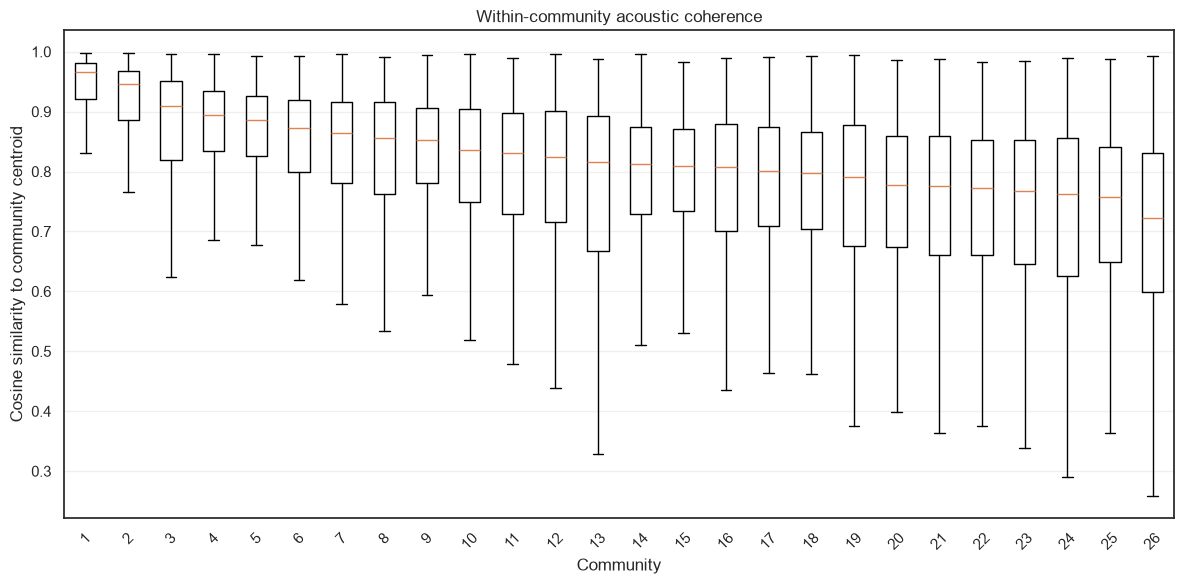

In [89]:
import matplotlib.pyplot as plt

community_order = (
    community_coherence_report
    .sort_values("cosine_median", ascending=False)
    .index
)

boxplot_data = [
    analysis_df.loc[
        analysis_df["community"] == community,
        "centroid_cosine_similarity"
    ].dropna()
    for community in community_order
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    label=community_order.astype(int).tolist(),
    showfliers=False
)

plt.xlabel("Community")
plt.ylabel("Cosine similarity to community centroid")
plt.title("Within-community acoustic coherence")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()